## Resources

### **Cell 1: Project Setup & Environment Initialization**

**What this does:** Initializes the environment, imports all necessary machine learning and visualization libraries, and sets the global random seed to ensure your results are 100% reproducible. It also prints the mandatory educational use disclaimer required by the lab manual.

In [1]:
# Phase 1: Project Setup, Educational Boundary & Environment Logging
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    cross_validate, cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef, brier_score_loss,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Educational Use Boundary
print("+" + "-"*87 + "+")
print("|" + " "*30 + "EDUCATIONAL USE DISCLAIMER" + " "*31 + "|")
print("| This predictive study uses public benchmark data for algorithm design. The models   |")
print("| are research prototypes, are NOT clinically validated diagnostic devices, MUST NOT  |")
print("| be used for direct patient care or triage, and do NOT constitute medical advice.  |")
print("+" + "-"*87 + "+")

# Log environment versions for reproducibility
print("\n--- Environment Versions ---")
print(f"Python: {platform.python_version()} | NumPy: {np.__version__} | pandas: {pd.__version__} | scikit-learn: {sklearn.__version__}")

# Set Global Seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

+---------------------------------------------------------------------------------------+
|                              EDUCATIONAL USE DISCLAIMER                               |
| This predictive study uses public benchmark data for algorithm design. The models   |
| are research prototypes, are NOT clinically validated diagnostic devices, MUST NOT  |
| be used for direct patient care or triage, and do NOT constitute medical advice.  |
+---------------------------------------------------------------------------------------+

--- Environment Versions ---
Python: 3.12.13 | NumPy: 2.0.2 | pandas: 2.2.2 | scikit-learn: 1.6.1


---

### **Cell 2: Data Audit & Strict Splitting**

**What this does:** Loads the primary Breast Cancer dataset, remaps the target variable so "Malignant" is correctly set as the positive class (1), and runs a data audit for missing values and duplicates. It then locks away 20% of the data as the final test set using a stratified split, ensuring no data leakage occurs during training.

In [2]:
# Phase 2: Core Dataset Load, Audit & Strict Splitting (Breast Cancer)
raw = load_breast_cancer(as_frame=True)
X = raw.data.copy()

# Remap target: 1 = Malignant (Positive Class), 0 = Benign
y = (raw.target == 0).astype(int)
y.name = "malignant"

# Data Audit
audit = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "unique": X.nunique(),
})
print("--- Data Audit: Breast Cancer ---")
print(f"Total rows: {len(X)}, Duplicates: {X.duplicated().sum()}")
print(f"Target distribution:\n{y.value_counts(normalize=True) * 100}")

# Create and Lock Final Test Set (80/20 Stratified Split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"\nTraining shape: {X_train.shape} | Test shape: {X_test.shape}")

--- Data Audit: Breast Cancer ---
Total rows: 569, Duplicates: 0
Target distribution:
malignant
0    62.741652
1    37.258348
Name: proportion, dtype: float64

Training shape: (455, 30) | Test shape: (114, 30)


---

### **Cell 3: Exploratory Data Analysis & Overfitting Diagnosis**

**What this does:** Performs Exploratory Data Analysis (EDA) specifically on the training data, visualizing class distributions, feature overlap, and feature correlation. It also trains an unconstrained Decision Tree to demonstrate how a basic tree perfectly memorizes the training data (100% accuracy), leading to extreme overfitting.

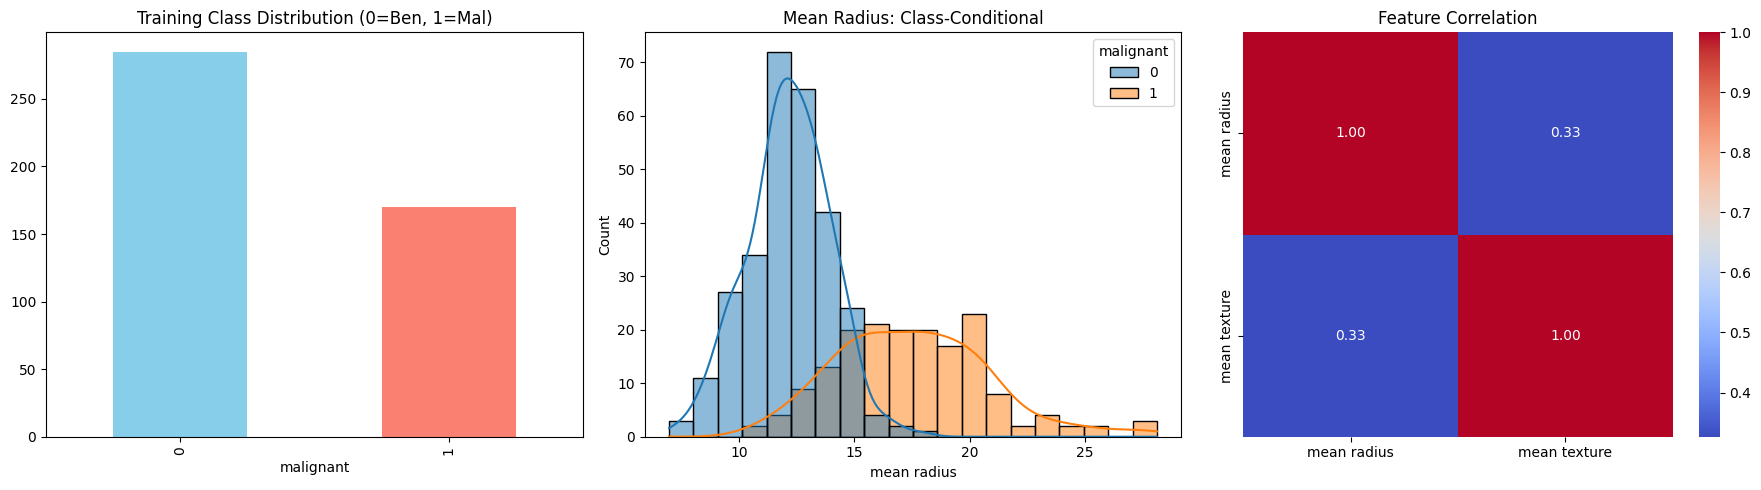

Unconstrained Tree Depth: 8 | Leaves: 24
Training Accuracy: 1.0000 (Perfect memorization)


In [3]:
# Phase 3: Exploratory Data Analysis & Baseline Overfitting Diagnosis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
y_train.value_counts().sort_index().plot(kind="bar", ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title("Training Class Distribution (0=Ben, 1=Mal)")

selected = ["mean radius", "mean texture"]
eda_df = X_train[selected].copy()
eda_df["malignant"] = y_train.values
sns.histplot(data=eda_df, x="mean radius", hue="malignant", kde=True, ax=axes[1])
axes[1].set_title("Mean Radius: Class-Conditional")

sns.heatmap(X_train[selected].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[2])
axes[2].set_title("Feature Correlation")
plt.tight_layout()
plt.show()

# Demonstrate unconstrained tree overfitting
tree_full = DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE)
tree_full.fit(X_train, y_train)

print(f"Unconstrained Tree Depth: {tree_full.get_depth()} | Leaves: {tree_full.get_n_leaves()}")
print(f"Training Accuracy: {accuracy_score(y_train, tree_full.predict(X_train)):.4f} (Perfect memorization)")

---

### **Cell 4: Tree Pruning & Cross-Validation Comparison**

**What this does:** This is the core model selection phase. It calculates the cost-complexity pruning path to find the best `ccp_alpha` penalty, keeping the tree simple. It then rigorously compares the Dummy Baseline, Basic CART, Pruned CART, and Random Forest using 5-fold cross-validation, printing a comprehensive metrics table.

In [5]:
# Phase 4: Cost-Complexity Pruning & 3-Model CV Comparison
from sklearn.metrics import make_scorer

scoring = {
    "accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy",
    "recall": "recall", "specificity": make_scorer(recall_score, pos_label=0),
    "precision": "precision", "f1": "f1",
    "roc_auc": "roc_auc", "pr_auc": "average_precision"
}

tree_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Extract alpha paths for pruning
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = np.unique(path.ccp_alphas[:-1])

# Tune Pruned Tree
prune_search = GridSearchCV(
    tree_pipe, param_grid={"model__ccp_alpha": ccp_alphas, "model__class_weight": [None, "balanced"]},
    scoring=scoring, refit="roc_auc", cv=cv, n_jobs=-1
)
prune_search.fit(X_train, y_train)
best_pruned_model = prune_search.best_estimator_

# The 3 Required Models + Dummy
models = {
    "Dummy baseline": DummyClassifier(strategy="prior"),
    "Basic CART": DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE),
    "Tuned and pruned CART": best_pruned_model,
    "Random Forest": RandomForestClassifier(n_estimators=300, max_features="sqrt", class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
}

# Run Cross Validation and compile comprehensive metrics
cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    cv_rows.append({
        "Model": name,
        "ROC-AUC (Mean ± SD)": f"{scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}",
        "PR-AUC (Mean)": f"{scores['test_pr_auc'].mean():.3f}",
        "Sensitivity (Mean)": f"{scores['test_recall'].mean():.3f}",
        "Balanced Acc (Mean)": f"{scores['test_balanced_accuracy'].mean():.3f}"
    })

print("--- 5-Fold Cross-Validation Model Comparison ---")
display(pd.DataFrame(cv_rows))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

--- 5-Fold Cross-Validation Model Comparison ---


,Model,ROC-AUC (Mean ± SD),PR-AUC (Mean),Sensitivity (Mean),Balanced Acc (Mean)
0,Dummy baseline,0.500 ± 0.000,0.374,0.000,0.500
1,Basic CART,0.917 ± 0.038,0.845,0.894,0.917
2,Tuned and pruned CART,0.948 ± 0.031,0.899,0.918,0.938
3,Random Forest,0.989 ± 0.007,0.988,0.941,0.958


---

### **Cell 5: Threshold Selection & Final Test Evaluation**

**What this does:** Automatically scans through probability thresholds using out-of-fold data to find the exact point that guarantees at least 90% sensitivity (prioritizing the detection of malignant tumors). It then runs the locked model on the test set *once* and generates the final, comprehensive dictionary of clinical metrics.

In [6]:
# Phase 5: Threshold Tuning and Final Locked Test Evaluation
TARGET_SENSITIVITY = 0.90
oof_prob = cross_val_predict(best_pruned_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

thresholds = np.linspace(0.05, 0.95, 100)
threshold_rows = []
for t in thresholds:
    pred = (oof_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0
    spec = tn / (tn + fp) if (tn + fp) else 0
    threshold_rows.append((t, sens, spec))

threshold_df = pd.DataFrame(threshold_rows, columns=["threshold", "sensitivity", "specificity"])
# Select threshold that maximizes specificity while keeping sensitivity >= TARGET
selected_threshold = threshold_df[threshold_df["sensitivity"] >= TARGET_SENSITIVITY].sort_values("specificity", ascending=False).iloc[0]["threshold"]
print(f"Selected Operating Threshold: {selected_threshold:.3f}\n")

# --- FINAL TEST SET EVALUATION ---
final_model = best_pruned_model.fit(X_train, y_train)
test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= selected_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
test_metrics = {
    "Threshold": selected_threshold,
    "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    "Sensitivity": recall_score(y_test, test_pred),
    "Specificity": tn / (tn + fp),
    "Precision": precision_score(y_test, test_pred),
    "F1-Score": f1_score(y_test, test_pred),
    "ROC-AUC": roc_auc_score(y_test, test_prob),
    "PR-AUC": average_precision_score(y_test, test_prob),
    "Brier Score": brier_score_loss(y_test, test_prob),
    "MCC": matthews_corrcoef(y_test, test_pred)
}

print("--- Final Locked Test Results (Pruned CART) ---")
display(pd.Series(test_metrics).to_frame(name="Score"))

Selected Operating Threshold: 0.850

--- Final Locked Test Results (Pruned CART) ---


,Score
Threshold,0.850000
TN,69.000000
FP,3.000000
FN,5.000000
TP,37.000000
Sensitivity,0.880952
Specificity,0.958333
Precision,0.925000
F1-Score,0.902439
ROC-AUC,0.943122


---

### **Cell 6: Visual Diagnostics & Interpretability**

**What this does:** Plots the visual evidence required by the lab manual: the Confusion Matrix, the ROC curve, and the Precision-Recall (PR) curve. Finally, it renders the visual flowchart of the pruned Decision Tree so you can actually read the if/then logic.

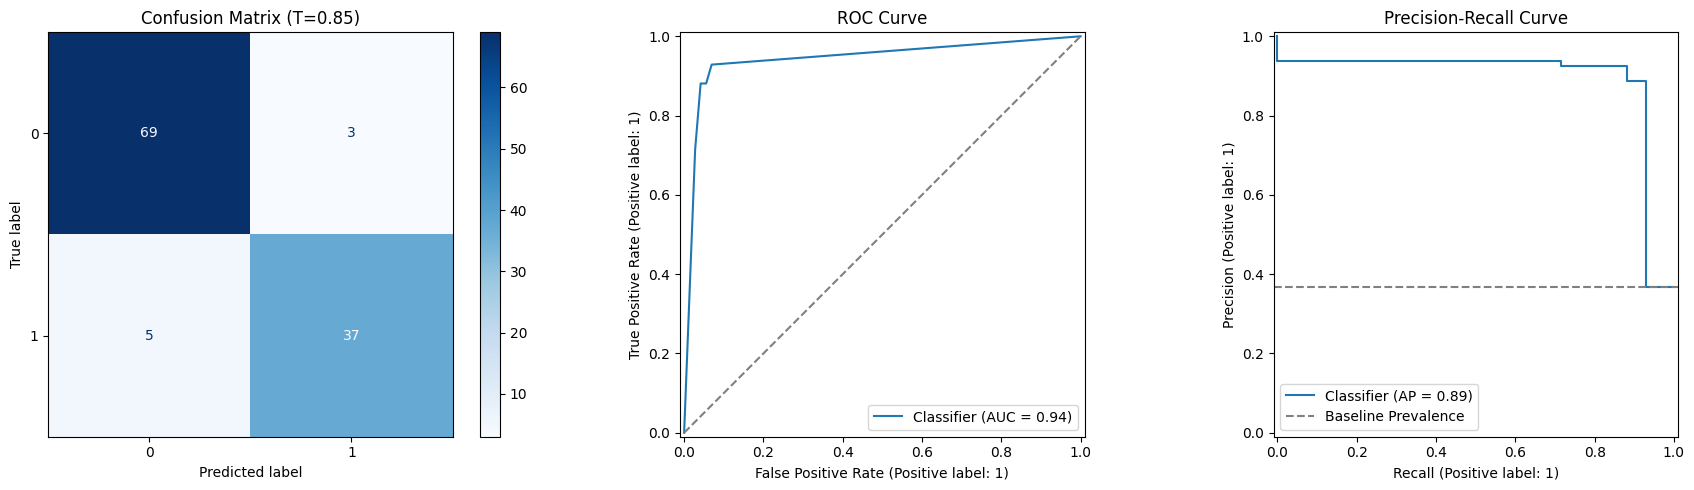

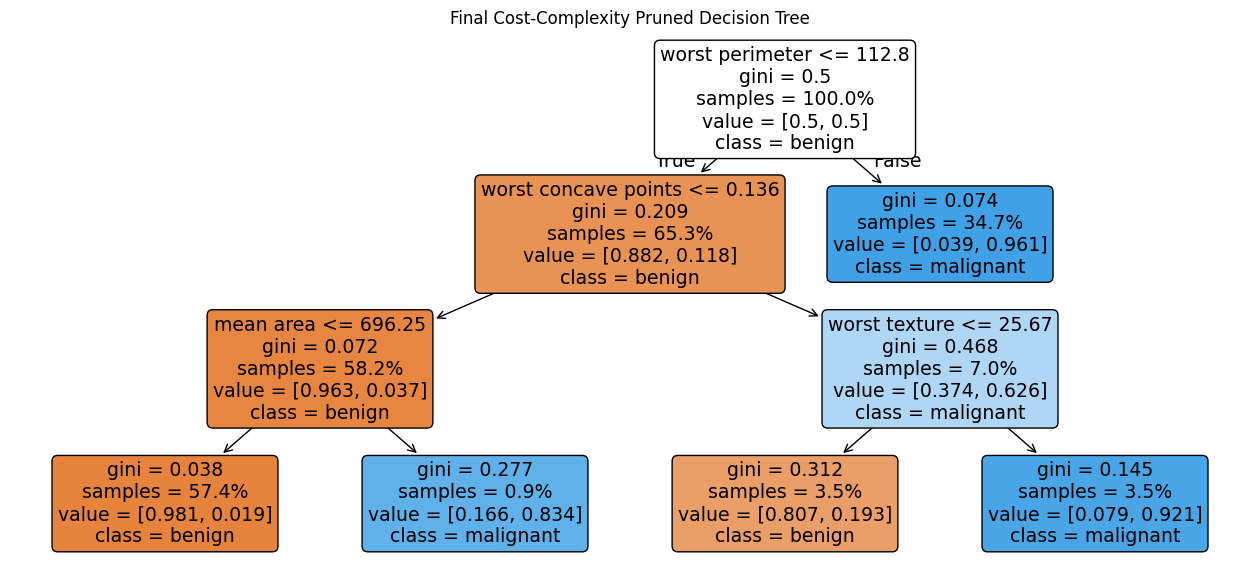

In [7]:
# Phase 6: Diagnostic Curves and Model Interpretability
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, cmap="Blues", ax=axes[0])
axes[0].set_title(f"Confusion Matrix (T={selected_threshold:.2f})")

RocCurveDisplay.from_predictions(y_test, test_prob, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, test_prob, ax=axes[2])
axes[2].axhline(y_test.mean(), linestyle="--", color="gray", label="Baseline Prevalence")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend()

plt.tight_layout()
plt.show()

# Plot the Final Pruned Tree
fitted_tree = final_model.named_steps["model"]
plt.figure(figsize=(16, 7))
plot_tree(fitted_tree, feature_names=X_train.columns, class_names=["benign", "malignant"], filled=True, rounded=True, proportion=True, precision=3)
plt.title("Final Cost-Complexity Pruned Decision Tree")
plt.show()

---

### **Cell 7: Path Tracing & Feature Importance**

**What this does:** Fulfills the interpretability requirement by extracting and printing the exact sequence of rules a specific patient took down the tree (for a True Positive, True Negative, and False Negative). It also calculates and compares the model's native Gini importance against Permutation importance to check for bias.

In [11]:
# Phase 7: Individual Case Path Tracing and Feature Importance
print("--- Individual Prediction Path Tracing ---")
# Find indices for 1 TP, 1 TN, 1 FN
tp_idx = np.where((y_test == 1) & (test_pred == 1))[0][0]
tn_idx = np.where((y_test == 0) & (test_pred == 0))[0][0]
fn_idx = np.where((y_test == 1) & (test_pred == 0))[0][0]

def trace_path(index, label_name):
    sample = X_test.iloc[[index]]
    # Pass .values to avoid UserWarning about feature names
    node_indicator = fitted_tree.decision_path(sample.values)
    leaf_id = fitted_tree.apply(sample.values)[0]
    path_nodes = node_indicator.indices

    print(f"\nCase {label_name} (Index {index}) - Actual: {y_test.iloc[index]}, Predicted: {test_pred[index]}, Probability: {test_prob[index]:.3f}")

    for node_id in path_nodes:
        if leaf_id == node_id:
            print(f"  -> Reached Leaf Node {node_id}")
        else:
            feature_idx = fitted_tree.tree_.feature[node_id]
            feature_name = X_train.columns[feature_idx]
            threshold = fitted_tree.tree_.threshold[node_id]
            value = sample[feature_name].values[0]
            direction = "<=" if value <= threshold else ">"
            print(f"  -> Node {node_id}: {feature_name} = {value:.3f} {direction} {threshold:.3f}")

trace_path(tp_idx, "True Positive")
trace_path(tn_idx, "True Negative")
trace_path(fn_idx, "False Negative")

# Feature Importance Comparison (Gini vs Permutation)
print("\n--- Feature Importance Comparison ---")
gini_imp = pd.Series(fitted_tree.feature_importances_, index=X_train.columns)
perm = permutation_importance(final_model, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE)
perm_imp = pd.Series(perm.importances_mean, index=X_train.columns)

imp_comparison = pd.DataFrame({"Gini (Impurity)": gini_imp, "Permutation (Predictive)": perm_imp})
imp_comparison = imp_comparison[imp_comparison.sum(axis=1) > 0].sort_values("Permutation (Predictive)", ascending=False)
display(imp_comparison.head(8))

--- Individual Prediction Path Tracing ---

Case True Positive (Index 1) - Actual: 1, Predicted: 1, Probability: 0.961
  -> Node 0: worst perimeter = 165.300 > 112.800
  -> Reached Leaf Node 8

Case True Negative (Index 0) - Actual: 0, Predicted: 0, Probability: 0.019
  -> Node 0: worst perimeter = 83.740 <= 112.800
  -> Node 1: worst concave points = 0.090 <= 0.136
  -> Node 2: mean area = 403.300 <= 696.250
  -> Reached Leaf Node 3

Case False Negative (Index 16) - Actual: 1, Predicted: 0, Probability: 0.193
  -> Node 0: worst perimeter = 110.300 <= 112.800
  -> Node 1: worst concave points = 0.138 > 0.136
  -> Node 5: worst texture = 20.860 <= 25.670
  -> Reached Leaf Node 6

--- Feature Importance Comparison ---


,Gini (Impurity),Permutation (Predictive)
worst perimeter,0.818839,0.222470
worst concave points,0.104559,0.094196
mean area,0.031944,0.005208
worst texture,0.044659,0.001835


---

### **Cell 8: Extended Study (Dataset 2)**

**What this does:** Satisfies the "Extended Study" requirement by bringing in a completely new medical dataset (UCI Heart Disease) that contains missing values. It sets up an imputation pipeline and runs the tree-based algorithms on this mixed-type data to prove transportability of the workflow.

In [10]:
# Phase 8: EXTENDED STUDY - Mixed-Type Data (Heart Disease Dataset)
print("--- Extended Study: UCI Heart Disease Dataset ---")
# Load dataset with missing values and categorical data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]
heart_data = pd.read_csv(url, names=columns, na_values="?")

# Target: 0 = No disease, 1-4 = Disease present. Remap to Binary (1 = Disease)
y_heart = (heart_data["target"] > 0).astype(int)
X_heart = heart_data.drop("target", axis=1)

print(f"Heart Data Loaded: {X_heart.shape}, Missing Values: {X_heart.isna().sum().sum()}")

X_htrain, X_htest, y_htrain, y_htest = train_test_split(
    X_heart, y_heart, test_size=0.20, stratify=y_heart, random_state=RANDOM_STATE
)

# Pipeline handling missing values for Heart Disease
heart_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Evaluate Random Forest vs Pruned CART on Dataset 2
h_models = {
    "Heart Basic CART": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Heart Tuned CART": GridSearchCV(heart_pipe, param_grid={"model__max_depth": [3, 5, 7], "model__min_samples_leaf": [2, 5]}, cv=5, scoring="roc_auc").fit(X_htrain, y_htrain).best_estimator_,
    "Heart Random Forest": Pipeline([("imp", SimpleImputer(strategy="median")), ("rf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))])
}

h_rows = []
for name, model in h_models.items():
    # Pipeline requires imputation before basic CART too
    if name == "Heart Basic CART":
        model = Pipeline([("imp", SimpleImputer(strategy="median")), ("cart", model)])
    scores = cross_validate(model, X_htrain, y_htrain, cv=5, scoring=scoring)
    h_rows.append({
        "Model": name,
        "ROC-AUC (Mean)": f"{scores['test_roc_auc'].mean():.3f}",
        "Sensitivity (Mean)": f"{scores['test_recall'].mean():.3f}"
    })
display(pd.DataFrame(h_rows))

--- Extended Study: UCI Heart Disease Dataset ---
Heart Data Loaded: (303, 13), Missing Values: 6


,Model,ROC-AUC (Mean),Sensitivity (Mean)
0,Heart Basic CART,0.739,0.683
1,Heart Tuned CART,0.813,0.666
2,Heart Random Forest,0.889,0.747


---

### **Cell 9: Robustness Experiment & Final Export**

**What this does:** Completes the final requirements by running a robustness test to see how tree depth and performance fluctuate when you change the random seed. Finally, it uses `joblib` and `pandas` to serialize (save) your trained model and metrics to files for submission.

In [12]:
# Phase 9: Robustness Analysis & Artifact Saving
print("--- Robustness Experiment: Split Stability across Random Seeds (Breast Cancer) ---")
stability_rows = []
for seed in [10, 42, 100, 999]:
    Xt, Xv, yt, yv = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)
    model = DecisionTreeClassifier(ccp_alpha=0.012, class_weight="balanced", random_state=seed)
    model.fit(Xt, yt)
    auc = roc_auc_score(yv, model.predict_proba(Xv)[:, 1])
    stability_rows.append({"Seed": seed, "Test ROC-AUC": auc, "Tree Depth": model.get_depth()})

display(pd.DataFrame(stability_rows))

# Save Artifacts
print("\n--- Saving Artifacts to Disk ---")
artifact = {
    "model": final_model,
    "threshold": float(selected_threshold),
    "positive_class": "malignant",
    "feature_names": list(X_train.columns),
    "random_state": RANDOM_STATE,
    "test_metrics": test_metrics,
    "intended_use": "Educational predictive-analytics laboratory only"
}

joblib.dump(artifact, "lab02_decision_tree_artifact.joblib")
pd.DataFrame([test_metrics]).to_csv("lab02_test_metrics.csv", index=False)
print("Saved: 'lab02_decision_tree_artifact.joblib' and 'lab02_test_metrics.csv'")

--- Robustness Experiment: Split Stability across Random Seeds (Breast Cancer) ---


,Seed,Test ROC-AUC,Tree Depth
0,10,0.978175,4
1,42,0.943122,3
2,100,0.931382,3
3,999,0.929894,4



--- Saving Artifacts to Disk ---
Saved: 'lab02_decision_tree_artifact.joblib' and 'lab02_test_metrics.csv'
